# Latent-TLG sweep — results

Visualizes the per-dataset latent-TLG GIC sweep (`make tlg-all-latent-gic`). Reads the
per-network JSON cache directly, so it works **while the sweep is still running** (partial)
and on the finished run — just re-run the cells as more networks complete.

- **Mean KL rank of each family across datasets** (lower = better; 1 = best fit).
- **Selected graphs per family** — for each model family, example graphs where it ranks #1,
  with the real vs. generated structure (clustering, assortativity, avg degree).

In [1]:
import json, glob
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

FAMILIES = ["TLG", "ER", "BA", "WS", "KR", "GRG", "SBM"]
CB = {"TLG":"#0072B2","ER":"#E69F00","BA":"#009E73","WS":"#CC79A7",
      "KR":"#D55E00","GRG":"#56B4E9","SBM":"#000000"}

def find_runs_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / "scripts" / "closedform" / "runs"
        if cand.exists():
            return cand
    raise RuntimeError("could not locate scripts/closedform/runs")

RUNS = find_runs_root()
print("runs root:", RUNS)

runs root: /Users/maruanottoni/home/master/research/all_logit/logit-graph/scripts/closedform/runs


In [2]:
# Load every cached network into a tidy (network x family) DataFrame
rows = []
for jp in glob.glob(str(RUNS / "tlg_latent_*_gic" / "cache" / "*.json")):
    try:
        d = json.loads(Path(jp).read_text())
    except Exception:
        continue
    if "families" not in d:
        continue
    fam = pd.DataFrame(d["families"])
    fam["kl_rank"] = fam["kl"].rank(method="min").astype(int)
    real = d.get("real", {})
    for _, r in fam.iterrows():
        rows.append(dict(
            dataset=d["dataset"], graph=str(d["id"]),
            real_nodes=real.get("nodes"), real_edges=real.get("edges"),
            real_clustering=real.get("clustering"),
            real_assortativity=real.get("assortativity"),
            real_avg_degree=real.get("avg_degree"),
            model=r["model"], kl=r["kl"], gic=r["gic"], n_params=r["n_params"],
            kl_rank=int(r["kl_rank"]),
            gen_edges=r.get("edges"), gen_avg_degree=r.get("avg_degree"),
            gen_clustering=r.get("clustering"), gen_assortativity=r.get("assortativity"),
        ))
df = pd.DataFrame(rows)
n_graphs = df.groupby("dataset")["graph"].nunique()
print(f"loaded {df['graph'].nunique()} networks across {df['dataset'].nunique()} datasets")
print(n_graphs.to_string())
df.head()

loaded 24 networks across 4 datasets
dataset
facebook     2
gplus        1
human        9
twitter     12


,dataset,graph,real_nodes,real_edges,real_clustering,real_assortativity,real_avg_degree,model,kl,gic,n_params,kl_rank,gen_edges,gen_avg_degree,gen_clustering,gen_assortativity
0,human,sub-OAS30760_ses-d3837_atlas-L2018_res-scale1_...,110,2692,0.71668,0.027956,48.945455,TLG,0.611636,9.223271,4,2,2692,48.945455,0.646281,0.204599
1,human,sub-OAS30760_ses-d3837_atlas-L2018_res-scale1_...,110,2692,0.71668,0.027956,48.945455,ER,0.967003,3.934006,1,4,2719,49.436364,0.452266,-0.018969
2,human,sub-OAS30760_ses-d3837_atlas-L2018_res-scale1_...,110,2692,0.71668,0.027956,48.945455,BA,0.690773,3.381546,1,3,2064,37.527273,0.455693,-0.120499
3,human,sub-OAS30760_ses-d3837_atlas-L2018_res-scale1_...,110,2692,0.71668,0.027956,48.945455,WS,3.769434,11.538869,2,7,2750,50.000000,0.723994,-0.021022
4,human,sub-OAS30760_ses-d3837_atlas-L2018_res-scale1_...,110,2692,0.71668,0.027956,48.945455,KR,1.163293,4.326585,1,6,2695,49.000000,0.437871,NaN


## Mean KL rank of families across datasets

Per dataset, every network ranks the 7 families by raw KL (1 = best). The table is the
mean rank per family per dataset; the bar chart is the **overall** mean rank
macro-averaged across datasets (each dataset weighted equally, so the large datasets
don't dominate).

In [3]:
# mean KL rank per (dataset, family) and overall macro-average
per_ds = (df.groupby(["dataset","model"])["kl_rank"].mean()
            .unstack("model")[FAMILIES])
overall = per_ds.mean(axis=0).sort_values()
winrate = (df.assign(win=(df.kl_rank==1).astype(float))
             .groupby(["dataset","model"])["win"].mean().unstack("model")[FAMILIES])

print("Overall mean KL rank (macro-averaged across datasets, lower=better):")
print(overall.round(3).to_string())
print("\nMean KL rank per dataset:")
display(per_ds[overall.index].round(2))
print("Win rate (fraction of a dataset's graphs where the family ranks #1):")
display((winrate[overall.index]*100).round(1))

Overall mean KL rank (macro-averaged across datasets, lower=better):
model
TLG    1.340
SBM    2.632
GRG    2.667
BA     4.667
ER     4.799
KR     5.333
WS     6.562

Mean KL rank per dataset:


model,TLG,SBM,GRG,BA,ER,KR,WS
dataset,,,,,,,
facebook,1.00,2.50,2.50,5.00,5.50,6.00,5.50
gplus,1.00,2.00,3.00,6.00,4.00,5.00,7.00
human,2.11,3.78,1.00,3.33,5.11,5.67,7.00
twitter,1.25,2.25,4.17,4.33,4.58,4.67,6.75


Win rate (fraction of a dataset's graphs where the family ranks #1):


model,TLG,SBM,GRG,BA,ER,KR,WS
dataset,,,,,,,
facebook,100.0,0.0,0.0,0.0,0.0,0.0,0.0
gplus,100.0,0.0,0.0,0.0,0.0,0.0,0.0
human,0.0,0.0,100.0,0.0,0.0,0.0,0.0
twitter,83.3,16.7,0.0,0.0,0.0,0.0,0.0


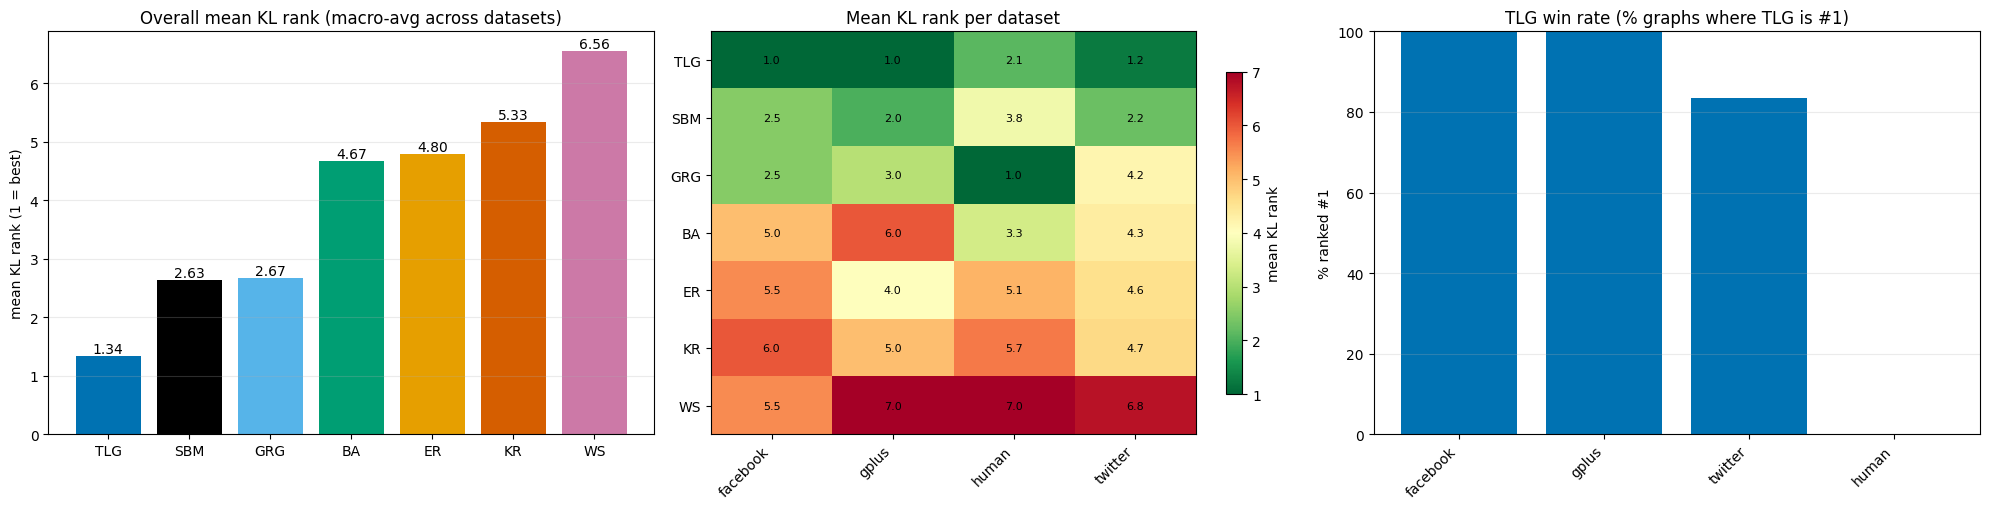

In [4]:
order = list(overall.index)
fig, ax = plt.subplots(1, 3, figsize=(20, 5.2))

# (1) overall mean rank
ax[0].bar(order, overall[order].values, color=[CB[m] for m in order])
ax[0].set_title("Overall mean KL rank (macro-avg across datasets)")
ax[0].set_ylabel("mean KL rank (1 = best)"); ax[0].grid(alpha=.25, axis="y")
for i,m in enumerate(order): ax[0].text(i, overall[m], f"{overall[m]:.2f}", ha="center", va="bottom")

# (2) per-dataset heatmap
H = per_ds[order].T
im = ax[1].imshow(H.values, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=7)
ax[1].set_xticks(range(H.shape[1])); ax[1].set_xticklabels(H.columns, rotation=45, ha="right")
ax[1].set_yticks(range(len(order))); ax[1].set_yticklabels(order)
ax[1].set_title("Mean KL rank per dataset")
for yi in range(len(order)):
    for xi in range(H.shape[1]):
        v = H.values[yi, xi]
        if np.isfinite(v): ax[1].text(xi, yi, f"{v:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax[1], shrink=.8, label="mean KL rank")

# (3) TLG win-rate per dataset
tlg_wr = (winrate["TLG"]*100).sort_values(ascending=False)
ax[2].bar(tlg_wr.index, tlg_wr.values, color=CB["TLG"])
ax[2].set_title("TLG win rate (% graphs where TLG is #1)")
ax[2].set_ylabel("% ranked #1"); ax[2].set_ylim(0,100)
ax[2].set_xticks(range(len(tlg_wr))); ax[2].set_xticklabels(tlg_wr.index, rotation=45, ha="right"); ax[2].grid(alpha=.25, axis="y")
plt.tight_layout(); plt.show()

## Selected graphs per family

For each family, a few graphs where it ranks **#1** on raw KL (its best fits), shown with
the **real vs. generated** structure. This is where you see *what each family captures*:
e.g. GRG matches spatial/clustered graphs, SBM dense communities, and TLG reproduces both
the degree and the clustering/community structure.

In [5]:
metric_cols = ["dataset","graph","real_nodes","kl",
               "real_clustering","gen_clustering",
               "real_assortativity","gen_assortativity",
               "real_avg_degree","gen_avg_degree"]
for fam in FAMILIES:
    sub = df[df.model==fam]
    wins = sub[sub.kl_rank==1].sort_values("kl")
    print(f"\n=== {fam}: ranked #1 on {len(wins)}/{sub['graph'].nunique()} graphs "
          f"(showing up to 3 best-KL examples) ===")
    if len(wins):
        display(wins[metric_cols].head(3).round(3).reset_index(drop=True))
    else:
        print("  (no #1 finishes yet)")


=== TLG: ranked #1 on 13/24 graphs (showing up to 3 best-KL examples) ===


,dataset,graph,real_nodes,kl,real_clustering,gen_clustering,real_assortativity,gen_assortativity,real_avg_degree,gen_avg_degree
0,twitter,22106463,156,0.038,0.487,0.464,0.076,0.323,18.000,18.000
1,twitter,174285878,228,0.044,0.494,0.299,-0.224,0.471,24.544,24.544
2,twitter,61086747,191,0.059,0.558,0.438,-0.265,0.398,37.037,37.037



=== ER: ranked #1 on 0/24 graphs (showing up to 3 best-KL examples) ===
  (no #1 finishes yet)

=== BA: ranked #1 on 0/24 graphs (showing up to 3 best-KL examples) ===
  (no #1 finishes yet)

=== WS: ranked #1 on 0/24 graphs (showing up to 3 best-KL examples) ===
  (no #1 finishes yet)

=== KR: ranked #1 on 0/24 graphs (showing up to 3 best-KL examples) ===
  (no #1 finishes yet)

=== GRG: ranked #1 on 9/24 graphs (showing up to 3 best-KL examples) ===


,dataset,graph,real_nodes,kl,real_clustering,gen_clustering,real_assortativity,gen_assortativity,real_avg_degree,gen_avg_degree
0,human,sub-OAS30572_ses-d0058_atlas-L2018_res-scale1_...,110,0.179,0.744,0.725,0.004,0.278,54.582,36.964
1,human,sub-OAS31072_ses-d3537_atlas-L2018_res-scale1_...,110,0.187,0.737,0.724,0.002,0.274,54.127,36.655
2,human,sub-OAS30610_ses-d0079_atlas-L2018_res-scale1_...,110,0.201,0.720,0.716,0.027,0.299,50.073,34.491



=== SBM: ranked #1 on 2/24 graphs (showing up to 3 best-KL examples) ===


,dataset,graph,real_nodes,kl,real_clustering,gen_clustering,real_assortativity,gen_assortativity,real_avg_degree,gen_avg_degree
0,twitter,528575851,82,0.365,0.649,0.474,-0.114,0.437,27.707,28.634
1,twitter,16105942,51,0.528,0.651,0.389,-0.205,0.015,18.314,18.235


### How well does each family reproduce structure?

Real vs. generated **clustering** and **assortativity** for TLG and SBM across all fitted
graphs (points on the dashed y=x line = perfect structural match).

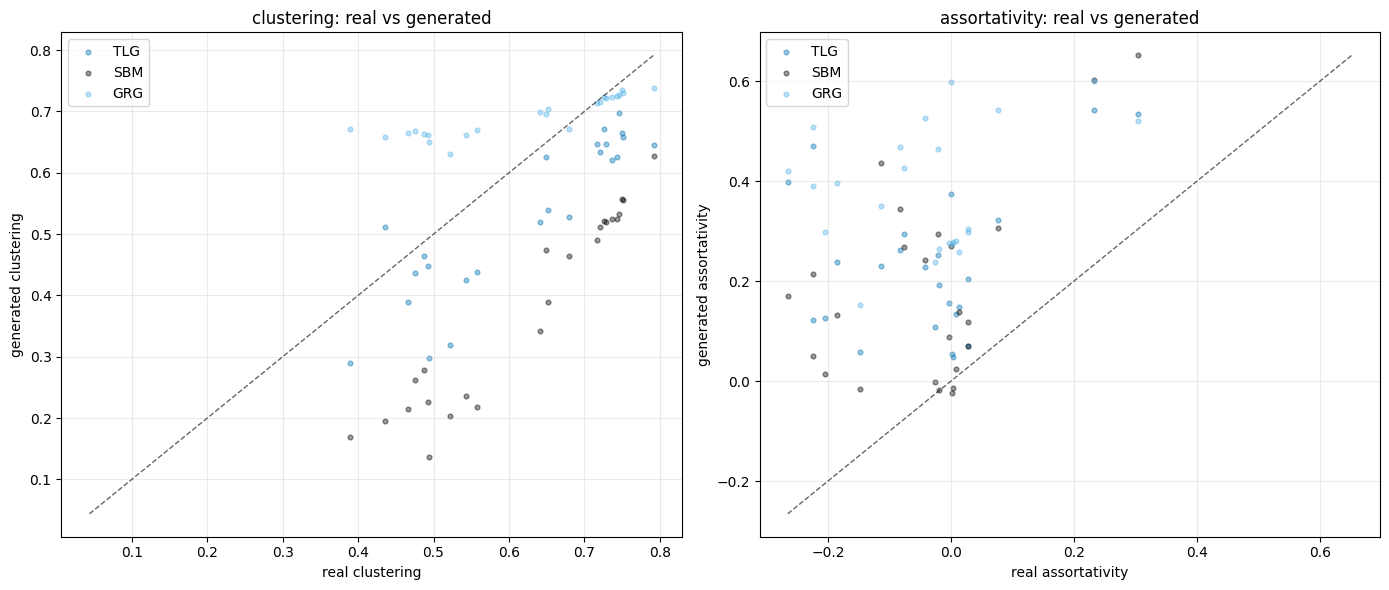

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for j,(metric,real_c,gen_c) in enumerate([
        ("clustering","real_clustering","gen_clustering"),
        ("assortativity","real_assortativity","gen_assortativity")]):
    for fam in ["TLG","SBM","GRG"]:
        s = df[(df.model==fam)].dropna(subset=[real_c,gen_c])
        ax[j].scatter(s[real_c], s[gen_c], s=12, alpha=.4, color=CB[fam], label=fam)
    lo = min(df[real_c].min(), df[gen_c].min())
    hi = max(df[real_c].max(), df[gen_c].max())
    ax[j].plot([lo,hi],[lo,hi], "k--", lw=1, alpha=.6)
    ax[j].set_xlabel(f"real {metric}"); ax[j].set_ylabel(f"generated {metric}")
    ax[j].set_title(f"{metric}: real vs generated"); ax[j].legend(); ax[j].grid(alpha=.25)
plt.tight_layout(); plt.show()

## Edge count: real vs. each family

For a few representative graphs (the largest per dataset), the real edge count vs. each
family's generated graph. TLG (budgeted growth) and SBM match `E_real` essentially by
construction; the closed-form families (ER/BA/WS/KR/GRG) only approximate it via their
moment-matched parameters.

In [ ]:
# raw per-network records (for tlg_trace + per-family generated-graph edges)
raw = {}
for jp in glob.glob(str(RUNS / "tlg_latent_*_gic" / "cache" / "*.json")):
    try: d = json.loads(Path(jp).read_text())
    except Exception: continue
    if "families" in d and "real" in d:
        raw[(d["dataset"], str(d["id"]))] = d

# one graph per dataset: the one with the most real edges
sel = []
for ds, grp in df.groupby("dataset"):
    g = grp.sort_values("real_edges", ascending=False)["graph"].iloc[0]
    if (ds, g) in raw: sel.append((ds, g))

fig, axes = plt.subplots(1, len(sel), figsize=(3.6*len(sel), 4.6), squeeze=False)
for ax, (ds, g) in zip(axes[0], sel):
    d = raw[(ds, g)]
    real_e = d["real"]["edges"]
    fam_e = {f["model"]: f.get("edges") for f in d["families"]}
    labels = ["real"] + FAMILIES
    vals = [real_e] + [fam_e.get(m) for m in FAMILIES]
    colors = ["#444444"] + [CB[m] for m in FAMILIES]
    ax.bar(range(len(labels)), vals, color=colors)
    ax.axhline(real_e, color="#444444", ls="--", lw=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(f"{ds}/{g}\n n={d['real']['nodes']}, real E={real_e}", fontsize=9)
    ax.set_ylabel("edges"); ax.grid(alpha=.2, axis="y")
plt.tight_layout(); plt.show()

## GIC selection trajectory of TLG fits

The latent model has no per-growth-step GIC (budgeted growth + one ensemble-mean KL), so
the saved trajectory is the **model-selection grid**: GIC = 2·KL + 2·n_params for every
`(degree-depth d, latent kernel, rank k)` config the fit evaluated, in evaluation order.
The red ring marks the **selected** config (minimum held-out KL).

In [ ]:
def tlabel(t): return f"d{t['d']}/{t['kernel'][:2]}/k{t['k']}"

# one graph per dataset that has a trace
pick, seen = [], set()
for (ds, g), d in sorted(raw.items()):
    if d.get("tlg_trace") and ds not in seen:
        seen.add(ds); pick.append((ds, g))

fig, ax = plt.subplots(figsize=(13, 5.6))
labels = None
for ds, g in pick:
    tr = raw[(ds, g)]["tlg_trace"]
    gic = [t["gic"] for t in tr]
    ax.plot(range(len(gic)), gic, marker="o", ms=4, lw=1.4, label=f"{ds}/{g} (n={raw[(ds,g)]['real']['nodes']})")
    bi = int(np.argmin([t["eval_kl"] for t in tr]))
    ax.scatter([bi], [gic[bi]], s=150, facecolors="none", edgecolors="red", linewidths=2, zorder=5)
    if labels is None or len(tr) > len(labels): labels = [tlabel(t) for t in tr]
if labels:
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("config: degree-depth d / latent kernel / rank k")
ax.set_ylabel("GIC = 2·KL + 2·n_params"); ax.grid(alpha=.25)
ax.set_title("TLG selection trajectory across the d×kernel×rank grid (red ring = selected)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()